# Q4: Emotion-Based Intent Classification Chatbot

This notebook trains an intent-based text classification model on the **Emotion Analysis Dataset** containing 422,000+ labeled sentences across 6 emotion classes:
- 😊 **Joy** — 143,067 samples
- 😢 **Sadness** — 121,187 samples
- 😠 **Anger** — 59,317 samples
- 😨 **Fear** — 49,649 samples
- ❤️ **Love** — 34,554 samples
- 😲 **Surprise** — 14,972 samples

After training, the model is used as an **interactive chat assistant**: when a user types any message, the model predicts the underlying emotion and responds with a contextually meaningful, randomly chosen message for that emotion class.

## 1. Install Dependencies

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn nltk joblib --quiet

## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Load & Explore the Dataset

In [3]:
# Load the combined emotion dataset
df = pd.read_csv('archive/combined_emotion.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (422746, 2)

Column names: ['sentence', 'emotion']

First 5 rows:


,sentence,emotion
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,sad
2,i gave up my internship with the dmrg and am f...,fear
3,i dont know i feel so lost,sad
4,i am a kindergarten teacher and i am thoroughl...,fear


In [4]:
# Rename columns for clarity
df.columns = ['text', 'emotion']

# Drop nulls
df.dropna(inplace=True)
df = df[df['text'].str.strip() != '']

print(f"Clean dataset shape: {df.shape}")
print(f"\nEmotion label distribution:")
print(df['emotion'].value_counts())

Clean dataset shape: (422746, 2)

Emotion label distribution:
emotion
joy        143067
sad        121187
anger       59317
fear        49649
love        34554
suprise     14972
Name: count, dtype: int64


In [5]:
# Normalize labels: lowercase and strip whitespace
df['emotion'] = df['emotion'].str.lower().str.strip()

# Map label variants to canonical names
label_map = {
    'sad': 'sadness',
    'happy': 'joy',
    'happiness': 'joy',
    'angry': 'anger',
    'scared': 'fear',
    'surprised': 'surprise',
    'loved': 'love',
    'joy': 'joy',
    'sadness': 'sadness',
    'anger': 'anger',
    'fear': 'fear',
    'love': 'love',
    'surprise': 'surprise'
}
df['emotion'] = df['emotion'].map(label_map)
df.dropna(subset=['emotion'], inplace=True)

print("Normalized emotion counts:")
print(df['emotion'].value_counts())

Normalized emotion counts:
emotion
joy        143067
sadness    121187
anger       59317
fear        49649
love        34554
Name: count, dtype: int64


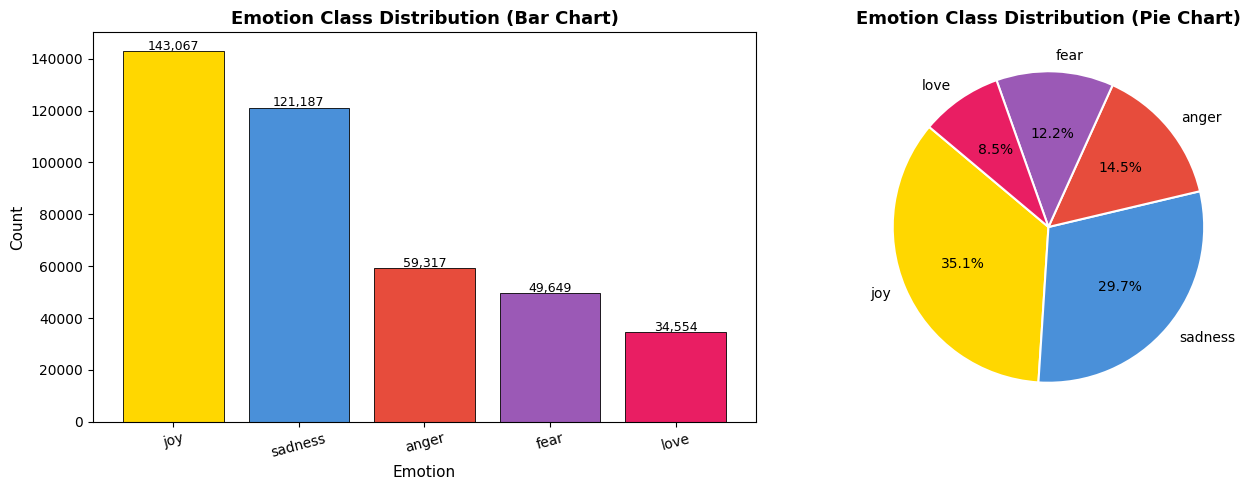

Distribution plot saved as class_distribution.png


In [6]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emotion_counts = df['emotion'].value_counts()
colors = ['#FFD700', '#4A90D9', '#E74C3C', '#9B59B6', '#E91E63', '#2ECC71']

# Bar chart
axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title('Emotion Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(
    emotion_counts.values,
    labels=emotion_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Emotion Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution plot saved as class_distribution.png")

## 4. Text Preprocessing

In [7]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
# Keep negation words — they carry emotional signal
negation_words = {'no', 'not', 'nor', 'never', 'neither', "n't"}
stop_words -= negation_words

def preprocess_text(text):
    """Clean and normalize a text string for emotion classification."""
    text = str(text).lower()
    # Expand common contractions
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

print("Preprocessing text (this may take a couple of minutes for 422k rows)...")
df['clean_text'] = df['text'].apply(preprocess_text)
print("Done!")

# Show before / after
sample_idx = 0
print(f"\nOriginal: {df['text'].iloc[sample_idx]}")
print(f"Cleaned:  {df['clean_text'].iloc[sample_idx]}")
print(f"Emotion:  {df['emotion'].iloc[sample_idx]}")

Preprocessing text (this may take a couple of minutes for 422k rows)...


Done!

Original: i just feel really helpless and heavy hearted
Cleaned:  feel really helpless heavy hearted
Emotion:  fear


## 5. Train / Test Split

In [8]:
X = df['clean_text']
y = df['emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"\nClass balance in train set:")
print(y_train.value_counts())

Training samples : 326,219
Test samples     : 81,555

Class balance in train set:
emotion
joy        114453
sadness     96950
anger       47454
fear        39719
love        27643
Name: count, dtype: int64


## 6. Build & Train the Classification Pipeline

We use a **TF-IDF vectorizer + Logistic Regression** pipeline — a strong, interpretable baseline for text classification.

In [9]:
# Build the pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,      # top 50k most frequent terms
        ngram_range=(1, 2),      # unigrams + bigrams for richer context
        sublinear_tf=True,       # apply log normalization to TF
        min_df=2,                # ignore very rare terms
        max_df=0.95              # ignore overly common terms
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=5.0,                   # regularization strength (lower = more regularized)
        solver='saga',           # fast solver; natively supports multinomial & parallelisation
        n_jobs=-1,               # use all CPU cores
        random_state=42
    ))
])

print("Training the model...")
pipeline.fit(X_train, y_train)
print("Training complete!")

Training the model...


Training complete!


## 7. Evaluate the Model

In [10]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Test Accuracy: 0.9115 (91.15%)

Classification Report:


              precision    recall  f1-score   support

       anger       0.90      0.91      0.90     11863
        fear       0.90      0.90      0.90      9930
         joy       0.92      0.93      0.93     28614
        love       0.75      0.73      0.74      6911
     sadness       0.95      0.95      0.95     24237

    accuracy                           0.91     81555
   macro avg       0.89      0.88      0.88     81555
weighted avg       0.91      0.91      0.91     81555



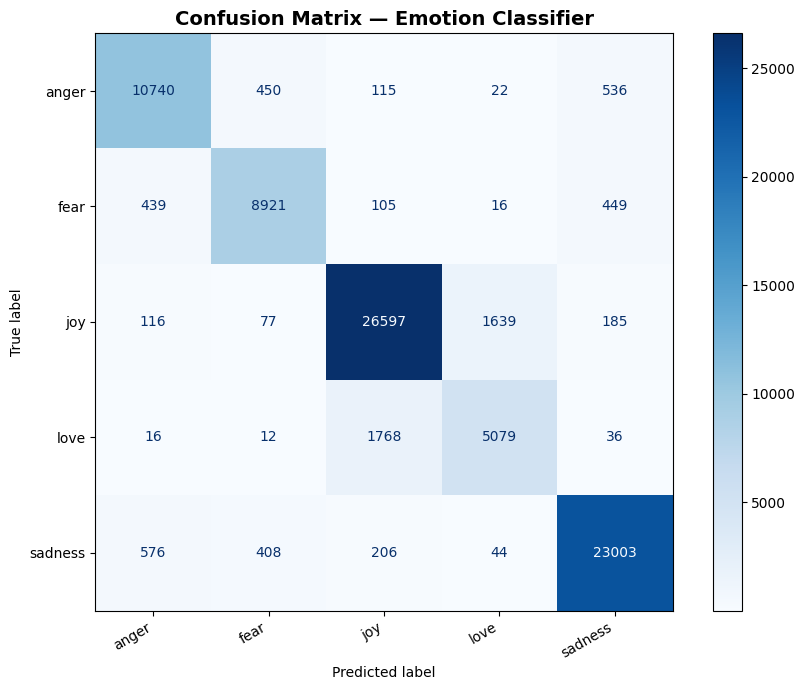

Confusion matrix saved as confusion_matrix.png


In [11]:
# Confusion matrix
labels = sorted(df['emotion'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Emotion Classifier', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

## 8. Save the Trained Model

In [12]:
joblib.dump(pipeline, 'emotion_classifier.pkl')
print("Model saved as emotion_classifier.pkl")

Model saved as emotion_classifier.pkl


## 9. Define Chatbot Response Library

For each predicted emotion, we define a bank of diverse, empathetic, context-aware responses. The chatbot picks one at random each time.

In [13]:
EMOTION_RESPONSES = {
    "joy": [
        "😊 That's wonderful! Your happiness is contagious — keep spreading those good vibes!",
        "🌟 I can feel your excitement! It sounds like things are going really well for you.",
        "🎉 Amazing! Moments of joy like this are worth cherishing. Hope it lasts long!",
        "✨ You're radiating positive energy! What a great thing to be experiencing.",
        "😄 Life is beautiful, isn't it? So glad you're feeling this way!",
        "🌈 That spark of happiness you have right now? Hold onto it tight!",
        "🎊 Celebrations are in order! You sound absolutely thrilled — and rightfully so.",
        "💛 Pure joy is rare and precious. Sounds like you've found a good reason to smile today!"
    ],
    "sadness": [
        "💙 I'm sorry you're feeling this way. It's okay to feel sad — your emotions are valid.",
        "🌧️ Tough times don't last. Allow yourself to feel this, and know that better days are ahead.",
        "🤗 Sending you a virtual hug. Whatever you're going through, you don't have to face it alone.",
        "💔 It's okay to not be okay sometimes. Take it one step at a time — you've got this.",
        "🕊️ Sadness is a part of life, but it's not the whole story. Hang in there.",
        "🫂 Your feelings matter. Give yourself permission to rest and heal at your own pace.",
        "🌱 Even in sadness, there is growth. You are stronger than you think.",
        "🌙 Not every night lasts forever. The sun will rise again — keep going."
    ],
    "anger": [
        "🔥 I can sense that frustration. Take a deep breath — it's okay to feel angry sometimes.",
        "😤 That sounds really frustrating. Try to step away for a moment if you can.",
        "⚡ Your anger is valid. Channel that energy into something constructive when you're ready.",
        "🧘 It's completely normal to feel this way. A few deep breaths can help reset your mind.",
        "🌊 Strong emotions like anger can be overwhelming. Give yourself space to process it.",
        "🛡️ Sometimes things feel unfair and it's reasonable to be upset. You deserve to be heard.",
        "💢 Recognized your anger — now try to understand what's behind it. That might help.",
        "🏃 If you can, go for a walk or do something physical. It really helps release that tension."
    ],
    "fear": [
        "😨 Fear is the mind's way of trying to protect you. You are safe, and you can handle this.",
        "🌟 Courage isn't the absence of fear — it's moving forward despite it. You can do this.",
        "🫶 Whatever is worrying you, remember: you've overcome challenges before. You will again.",
        "🌿 Take a slow, deep breath. Grounding yourself in the present can help ease anxiety.",
        "🔒 It's natural to be afraid. But don't let fear make your decisions for you.",
        "🌅 Beyond every fear lies the opportunity to grow. Trust yourself a little more.",
        "🤝 You're not alone in feeling this way. Many people share these fears — and they persevere.",
        "🧭 Feel the fear, acknowledge it, and then take one small step forward anyway."
    ],
    "love": [
        "❤️ Love is truly one of the most beautiful human experiences. Cherish it!",
        "💕 It sounds like your heart is full. That warmth is something very special.",
        "🌸 Love in any form — romantic, friendly, familial — is a gift. Hold it close.",
        "💖 There's something magical about feeling deeply connected to someone or something.",
        "🥰 That feeling of love you have? It's one of the most powerful forces in the world.",
        "🕊️ Love transforms us and the world around us. What a beautiful thing to feel!",
        "💌 Whether it's new love or something long-lasting, it's always worth celebrating.",
        "✨ You deserve all the love you feel — and just as much in return."
    ],
    "surprise": [
        "😲 Wow, sounds like something unexpected happened! How are you feeling about it?",
        "🎉 Life is full of surprises — some of the best things are completely unexpected!",
        "😮 That must have caught you completely off guard! Take a moment to process it.",
        "🌠 Sometimes the universe throws curveballs — good or bad, they shape our story.",
        "🤩 Surprises can be thrilling! How exciting to have something unexpected happen.",
        "🎊 Whether it was a pleasant or shocking surprise, life just got a lot more interesting!",
        "🔮 The unexpected is what makes life unpredictable and exciting. Embrace it!",
        "👀 Sounds like quite the twist! Hope it turns out to be a good one for you."
    ]
}

EMOTION_EMOJIS = {
    'joy': '😊 Joy',
    'sadness': '😢 Sadness',
    'anger': '😠 Anger',
    'fear': '😨 Fear',
    'love': '❤️ Love',
    'surprise': '😲 Surprise'
}

print("Response library loaded! Defined", sum(len(v) for v in EMOTION_RESPONSES.values()), "unique responses across", len(EMOTION_RESPONSES), "emotions.")

Response library loaded! Defined 48 unique responses across 6 emotions.


## 10. Chatbot Inference Function

In [14]:
def predict_emotion(text, model=pipeline):
    """Predict the emotion label and confidence for a given text."""
    cleaned = preprocess_text(text)
    if not cleaned.strip():
        return 'joy', 0.0  # default fallback
    pred_label = model.predict([cleaned])[0]
    proba = model.predict_proba([cleaned])[0]
    classes = model.classes_
    confidence = proba[list(classes).index(pred_label)] * 100
    return pred_label, confidence


def chatbot_response(user_input):
    """
    Given user input, predict the emotion and return:
    - The detected emotion label
    - Confidence score
    - A randomly chosen empathetic response for that emotion
    """
    if not user_input.strip():
        return {
            'emotion': 'unknown',
            'confidence': 0.0,
            'response': "Please type something so I can understand how you're feeling! 😊"
        }

    emotion, confidence = predict_emotion(user_input)
    response = random.choice(EMOTION_RESPONSES.get(emotion, ["I'm here for you! 😊"]))

    return {
        'emotion': emotion,
        'confidence': round(confidence, 2),
        'response': response
    }


def display_chat(user_input):
    """Pretty-print a single chatbot exchange."""
    result = chatbot_response(user_input)
    emotion_display = EMOTION_EMOJIS.get(result['emotion'], result['emotion'].title())
    print(f"{'='*60}")
    print(f"  You   : {user_input}")
    print(f"{'─'*60}")
    print(f"  Detected Emotion : {emotion_display} ({result['confidence']}% confidence)")
    print(f"{'─'*60}")
    print(f"  Bot   : {result['response']}")
    print(f"{'='*60}\n")


print("Chatbot functions defined!")

Chatbot functions defined!


## 11. Demo: Test the Chatbot on Sample Queries

In [15]:
test_queries = [
    "I just got promoted at work, I'm so happy right now!",
    "I miss my grandmother so much, it hurts every day.",
    "I can't believe how unfair this situation is, it makes me so mad!",
    "I'm terrified about my upcoming surgery, I can't sleep.",
    "I've never felt so deeply in love in my entire life.",
    "I just found out I won the lottery — I didn't even expect it!"
]

print("\nEMOTION CHATBOT — DEMO RESPONSES\n")
for query in test_queries:
    display_chat(query)


EMOTION CHATBOT — DEMO RESPONSES

  You   : I just got promoted at work, I'm so happy right now!
────────────────────────────────────────────────────────────
  Detected Emotion : 😊 Joy (92.17% confidence)
────────────────────────────────────────────────────────────
  Bot   : 😄 Life is beautiful, isn't it? So glad you're feeling this way!

  You   : I miss my grandmother so much, it hurts every day.
────────────────────────────────────────────────────────────
  Detected Emotion : 😢 Sadness (93.27% confidence)
────────────────────────────────────────────────────────────
  Bot   : 🌙 Not every night lasts forever. The sun will rise again — keep going.

  You   : I can't believe how unfair this situation is, it makes me so mad!
────────────────────────────────────────────────────────────
  Detected Emotion : 😠 Anger (99.63% confidence)
────────────────────────────────────────────────────────────
  Bot   : 💢 Recognized your anger — now try to understand what's behind it. That might help.

 

## 13. Summary

| Item | Detail |
|---|---|
| **Dataset** | Combined Emotion Dataset (~422k sentences) |
| **Classes** | Joy, Sadness, Anger, Fear, Love, Surprise |
| **Preprocessing** | Lowercasing, contraction expansion, stopword removal (keeping negations), lemmatization |
| **Vectorization** | TF-IDF (unigrams + bigrams, top 50k features, sublinear TF) |
| **Classifier** | Logistic Regression (saga solver, C=5, n_jobs=-1) |
| **Chatbot Strategy** | Intent classification → random response from emotion-specific response bank |
| **Outputs** | `emotion_classifier.pkl`, `class_distribution.png`, `confusion_matrix.png` |